# Reusable PyTorch Training Pipeline

Goal: combine the training concepts learned so far into reusable functions.

Features:
- training and validation loops
- GPU support
- early stopping
- learning-rate scheduling
- loss history
- best-model restoration

In [6]:
import copy
import torch
from torch import nn

In [7]:
class BatchNormNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(1, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

In [8]:
from torch.utils.data import TensorDataset, DataLoader, random_split

torch.manual_seed(42)

x = torch.linspace(-3, 3, 120).reshape(-1, 1)

y = (
    0.5 * x**3
    - 2 * x**2
    + x
    + 3
)

y += 1.5 * torch.randn_like(y)

dataset = TensorDataset(x, y)

train_dataset, val_dataset = random_split(
    dataset,
    [60, 60],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=10,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=10,
    shuffle=False
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using:", device)


Using: cuda


In [9]:
# reusable training function

def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=500,
    scheduler=None,
    patience=None
):
    train_losses = []
    val_losses = []
    learning_rates = []

    best_val_loss = float("inf")
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(epochs):

        # -------------------
        # Training
        # -------------------

        model.train()
        train_loss = 0.0

        for xb, yb in train_loader:

            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            predictions = model(xb)

            loss = criterion(predictions, yb)

            loss.backward()

            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # -------------------
        # Validation
        # -------------------

        model.eval()
        val_loss = 0.0

        with torch.no_grad():

            for xb, yb in val_loader:

                xb = xb.to(device)
                yb = yb.to(device)

                predictions = model(xb)

                loss = criterion(predictions, yb)

                val_loss += loss.item()

        val_loss /= len(val_loader)

        # -------------------
        # Record metrics
        # -------------------

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]
        learning_rates.append(current_lr)

        # -------------------
        # Save best model
        # -------------------

        if val_loss < best_val_loss:

            best_val_loss = val_loss
            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1

        # -------------------
        # Learning-rate scheduler
        # -------------------

        if scheduler is not None:
            scheduler.step(val_loss)

        # -------------------
        # Progress
        # -------------------

        if epoch % 50 == 0:

            print(
                f"Epoch {epoch:4d} | "
                f"Train: {train_loss:.4f} | "
                f"Val: {val_loss:.4f} | "
                f"LR: {current_lr:.6f}"
            )

        # -------------------
        # Early stopping
        # -------------------

        if (
            patience is not None
            and epochs_without_improvement >= patience
        ):

            print(
                f"\nEarly stopping at epoch {epoch}"
            )

            break

    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "learning_rate": learning_rates,
        "best_val_loss": best_val_loss
    }

    return model, history

In [10]:
model = BatchNormNetwork().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [11]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=30
)

In [12]:
model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=1500,
    scheduler=scheduler,
    patience=100
)

Epoch    0 | Train: 87.8459 | Val: 77.9487 | LR: 0.001000
Epoch   50 | Train: 29.8106 | Val: 10.4058 | LR: 0.001000
Epoch  100 | Train: 16.2821 | Val: 12.5381 | LR: 0.000500
Epoch  150 | Train: 13.4431 | Val: 12.4637 | LR: 0.000500
Epoch  200 | Train: 7.8704 | Val: 9.1157 | LR: 0.000500
Epoch  250 | Train: 13.7463 | Val: 6.2899 | LR: 0.000125

Early stopping at epoch 272


In [13]:
print(
    "Best validation loss:",
    history["best_val_loss"]
)

Best validation loss: 3.2215964794158936


In [14]:
print(
    "Epochs actually trained:",
    len(history["train_loss"])
)

Epochs actually trained: 273


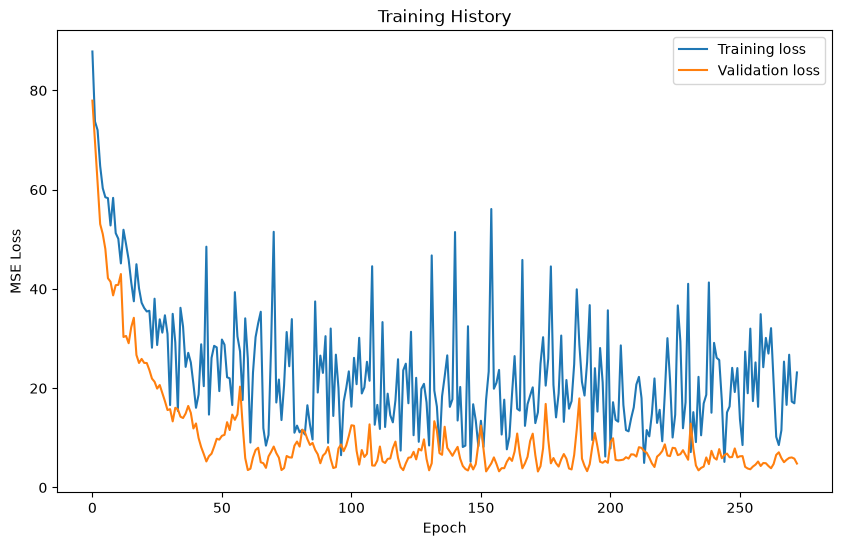

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    history["train_loss"],
    label="Training loss"
)

plt.plot(
    history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training History")
plt.legend()

plt.show()

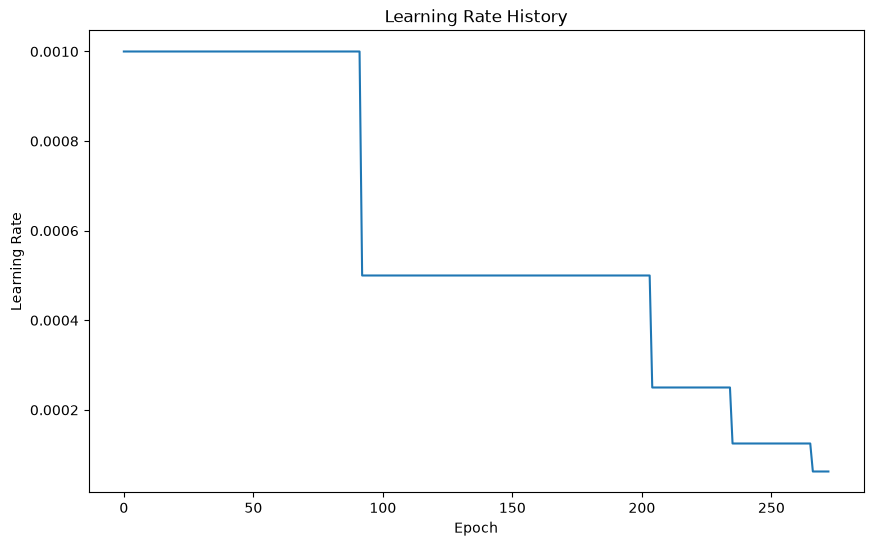

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(
    history["learning_rate"]
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate History")

plt.show()

In [17]:
history["train_loss"]
history["val_loss"]
history["learning_rate"]
history["best_val_loss"]

3.2215964794158936